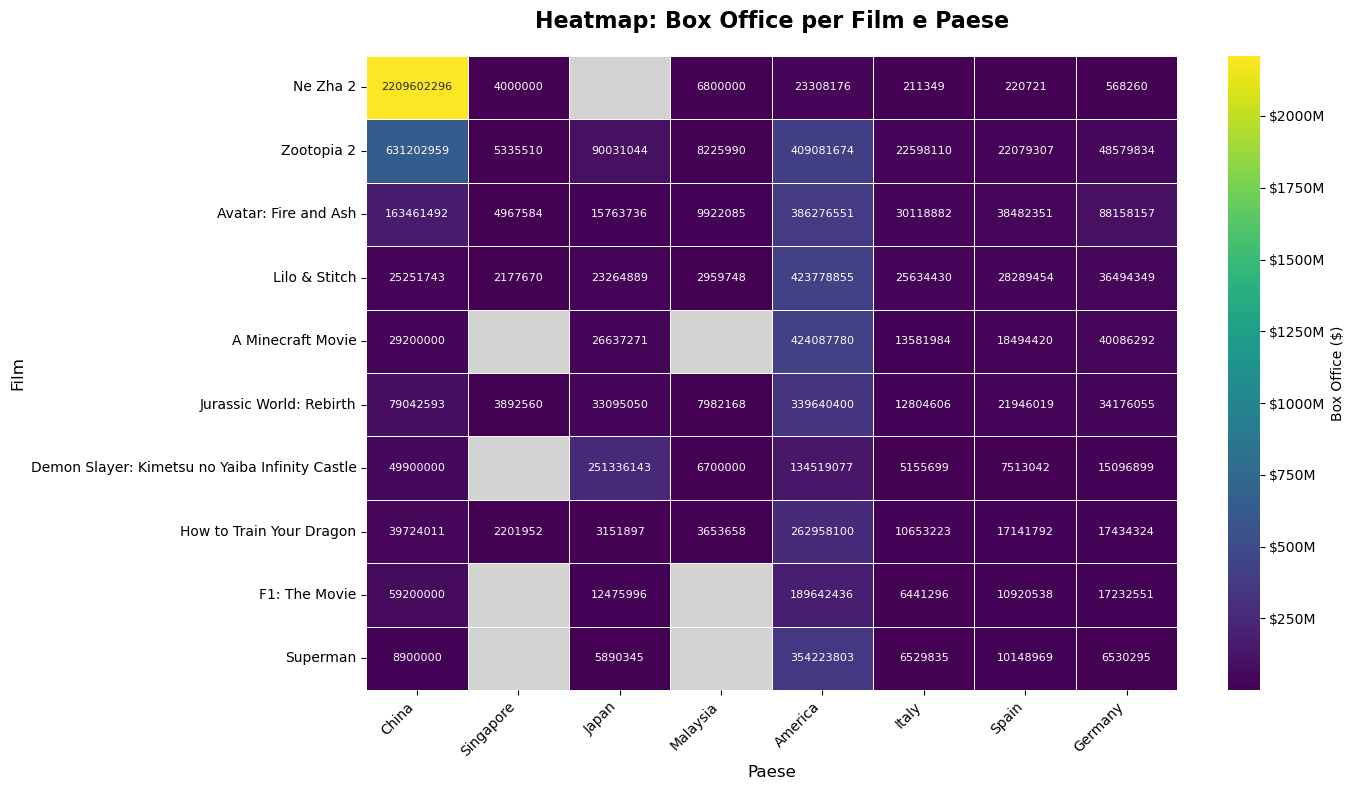

<Figure size 1200x600 with 0 Axes>

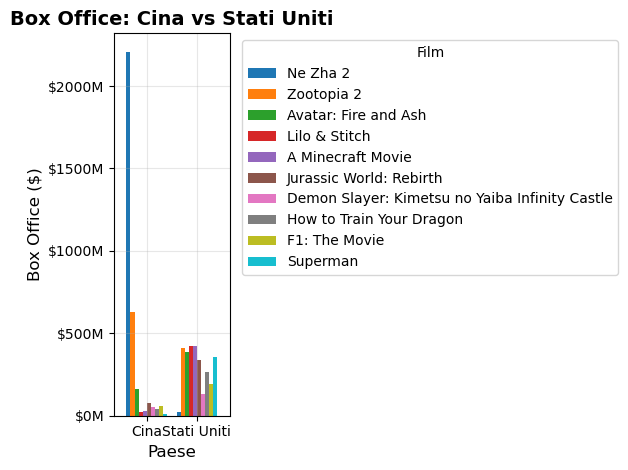

<Figure size 1200x600 with 0 Axes>

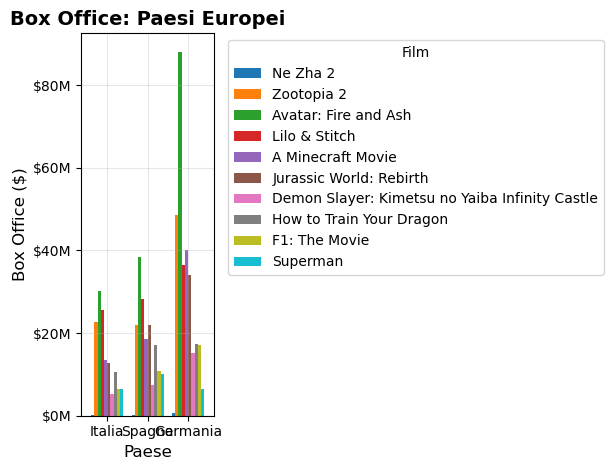

<Figure size 1200x600 with 0 Axes>

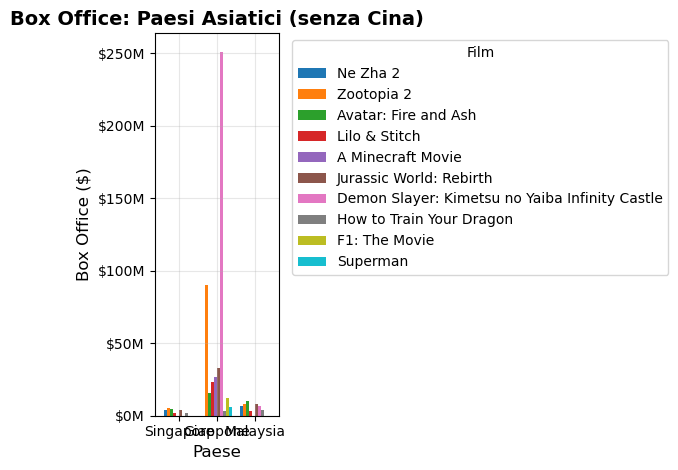

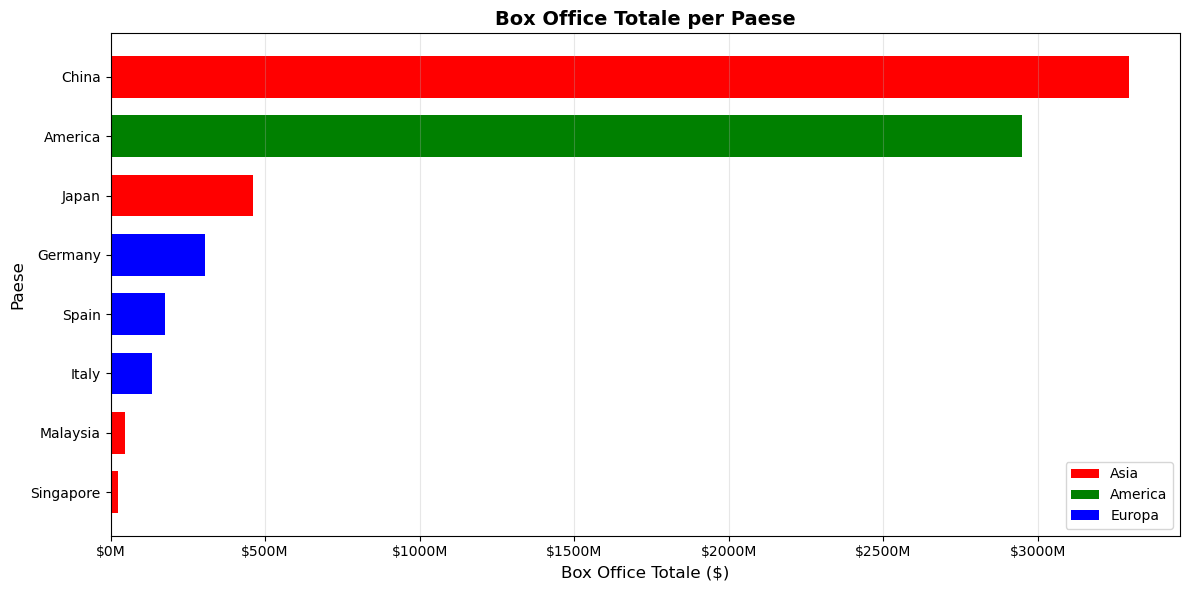

STATISTICHE DESCRITTIVE:

Box Office Totale per Paese (in milioni di $):
--------------------------------------------------
China           $3,295.5M
America         $2,947.5M
Japan           $461.6M
Germany         $304.4M
Spain           $175.2M
Italy           $133.7M
Malaysia        $46.2M
Singapore       $22.6M

--------------------------------------------------
Box Office Medio per Film in ogni Paese (in milioni di $):
--------------------------------------------------
China           $329.5M
Singapore       $3.8M
Japan           $51.3M
Malaysia        $6.6M
America         $294.8M
Italy           $13.4M
Spain           $17.5M
Germany         $30.4M

FILM CON IL MAGGIOR BOX OFFICE IN OGNI PAESE:
China           Ne Zha 2                                 $2,209.6M
Singapore       Zootopia 2                               $5.3M
Japan           Demon Slayer: Kimetsu no Yaiba Infinity Castle $251.3M
Malaysia        Avatar: Fire and Ash                     $9.9M
America         A Minecra

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# Leggi il file CSV
df = pd.read_csv('Nazione - Foglio1 (1).csv', header=[0,1])

# Pulizia dei dati
df.columns = df.columns.droplevel(0)  # Rimuovi il primo livello di intestazione
df = df.set_index('Nome film')

# Converti i valori in numeri
def clean_currency(value):
    if pd.isna(value) or value == '-':
        return np.nan
    try:
        return float(str(value).replace('$', '').replace(',', ''))
    except:
        return np.nan

# Applica la pulizia a tutte le colonne
for col in df.columns:
    df[col] = df[col].apply(clean_currency)

# 1. HEATMAP separata (più grande)
plt.figure(figsize=(14, 8))
heatmap_data = df.copy()

# Usa la nuova sintassi per evitare il warning
cmap = matplotlib.colormaps['viridis'].copy()
cmap.set_bad('lightgray')

# Crea la heatmap
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.0f',
            cmap=cmap,
            cbar_kws={'label': 'Box Office ($)'},
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 8})  # Riduci dimensione annotazioni

plt.title('Heatmap: Box Office per Film e Paese', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Paese', fontsize=12)
plt.ylabel('Film', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Formatta il colorbar in milioni
cbar = plt.gca().collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

# 2. ISTOGRAMMA Cina e Stati Uniti
plt.figure(figsize=(12, 6))
china_us_data = df[['China', 'America']].copy()
china_us_data.columns = ['Cina', 'Stati Uniti']

# Trasponi per avere paesi sulle ascisse
china_us_data.T.plot(kind='bar', width=0.8)
plt.title('Box Office: Cina vs Stati Uniti', fontsize=14, fontweight='bold')
plt.xlabel('Paese', fontsize=12)
plt.ylabel('Box Office ($)', fontsize=12)
plt.legend(title='Film', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

# 3. ISTOGRAMMA Paesi Europei
plt.figure(figsize=(12, 6))
europe_data = df[['Italy', 'Spain', 'Germany']].copy()
europe_data.columns = ['Italia', 'Spagna', 'Germania']

europe_data.T.plot(kind='bar', width=0.8)
plt.title('Box Office: Paesi Europei', fontsize=14, fontweight='bold')
plt.xlabel('Paese', fontsize=12)
plt.ylabel('Box Office ($)', fontsize=12)
plt.legend(title='Film', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

# 4. ISTOGRAMMA Paesi Asiatici (senza Cina)
plt.figure(figsize=(12, 6))
asia_no_china_data = df[['Singapore', 'Japan', 'Malaysia']].copy()
asia_no_china_data.columns = ['Singapore', 'Giappone', 'Malaysia']

asia_no_china_data.T.plot(kind='bar', width=0.8)
plt.title('Box Office: Paesi Asiatici (senza Cina)', fontsize=14, fontweight='bold')
plt.xlabel('Paese', fontsize=12)
plt.ylabel('Box Office ($)', fontsize=12)
plt.legend(title='Film', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

# 5. GRAFICO A BARRE ORIZZONTALE - Totale per paese
plt.figure(figsize=(12, 6))
total_by_country = df.sum()
total_by_country = total_by_country.sort_values(ascending=True)

# Assegna colori per continente
colors = []
for country in total_by_country.index:
    if country in ['China', 'Singapore', 'Japan', 'Malaysia']:
        colors.append('red')
    elif country == 'America':
        colors.append('green')
    else:  # Europe
        colors.append('blue')

bars = plt.barh(total_by_country.index, total_by_country.values, color=colors, height=0.7)
plt.title('Box Office Totale per Paese', fontsize=14, fontweight='bold')
plt.xlabel('Box Office Totale ($)', fontsize=12)
plt.ylabel('Paese', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
plt.gca().xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

# Aggiungi legenda per i colori
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='Asia'),
    Patch(facecolor='green', label='America'),
    Patch(facecolor='blue', label='Europa')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# Statistiche descrittive
print("=" * 80)
print("STATISTICHE DESCRITTIVE:")
print("=" * 80)

print("\nBox Office Totale per Paese (in milioni di $):")
print("-" * 50)
for country, total in total_by_country.sort_values(ascending=False).items():
    print(f"{country:15} ${total/1e6:,.1f}M")

print("\n" + "-" * 50)
print("Box Office Medio per Film in ogni Paese (in milioni di $):")
print("-" * 50)
for country in df.columns:
    avg = df[country].mean()
    print(f"{country:15} ${avg/1e6:,.1f}M")

print("\n" + "=" * 80)
print("FILM CON IL MAGGIOR BOX OFFICE IN OGNI PAESE:")
print("=" * 80)
for country in df.columns:
    max_film = df[country].idxmax()
    max_value = df[country].max()
    print(f"{country:15} {max_film:40} ${max_value/1e6:,.1f}M")